# Differentiable shallow water equations

This notebook solves the rotating shallow water equations (SWE) on the sphere
using the spectral methods provided by `torch-harmonics`. The SWE describe
the evolution of a thin fluid layer under gravity and rotation:

$$
\frac{\partial \mathbf{u}}{\partial t}
+ (\zeta + f)\,\hat{\mathbf{k}} \times \mathbf{u}
= -\nabla\left(\Phi + \tfrac12 |\mathbf{u}|^2\right),
\qquad
\frac{\partial \Phi}{\partial t}
+ \nabla \cdot (\Phi\,\mathbf{u}) = 0,
$$

where $\mathbf{u}$ is the horizontal velocity, $\zeta = \nabla \times \mathbf{u}$
the relative vorticity, $f$ the Coriolis parameter, and $\Phi = g h$ the
geopotential.

The solver works in spectral space (vorticity–divergence formulation) and uses
third-order Adams–Bashforth time integration. Because the SHT and all
operations are implemented as differentiable PyTorch modules, gradients can be
propagated through the entire time integration.

## Setup

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from math import ceil, floor
from tqdm.auto import tqdm

from torch_harmonics.examples import ShallowWaterSolver

/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Solver configuration

We set up a `ShallowWaterSolver` on a 512 × 1024 grid with spectral
truncation at $l_{\max} = 128$. The time step is 75 s and we integrate
for 12 simulated days (≈ 288 hours):

In [3]:
# initialize parameters:
nlat = 512
nlon = 2*nlat
lmax = ceil(128)
mmax = lmax
# timestepping
dt = 75
maxiter = 12*int(86400/dt)

# initialize solver class
swe_solver = ShallowWaterSolver(nlat, nlon, dt, lmax=lmax, mmax=mmax).to(device)

lons = swe_solver.lons
lats = swe_solver.lats

jj, ii = torch.triu_indices(lmax, mmax)

## Initial condition — Galewsky jet

The Galewsky test case initialises a barotropically unstable zonal jet
with a localised perturbation in the height field. The jet breaks up into
a train of vortices over several days, providing a stringent test of the
solver's accuracy and stability:

In [4]:
uspec0 = swe_solver.galewsky_initial_condition()    

/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Time integration

We integrate using third-order Adams–Bashforth. The first two steps
fall back to lower-order schemes (forward Euler, then second-order AB)
to bootstrap the multistep method. Hyperdiffusion is applied implicitly
to the vorticity and divergence fields to control grid-scale noise:

In [5]:
dudtspec = torch.zeros(3, 3, swe_solver.lmax, swe_solver.mmax, dtype=torch.complex128, device=device)
inew = 0
inow = 1
iold = 2

uspec = uspec0.clone().to(device)

# save for later:
nskip = 50
utspec = torch.zeros(floor(maxiter//nskip) + 1, *uspec.shape).cdouble().to(device)

pbar = tqdm(range(maxiter+1), desc="SWE integration")
with torch.inference_mode():
    for iter in pbar:
        t = iter*dt

        if iter % nskip == 0:
            utspec[iter//nskip] = uspec
            pbar.set_postfix_str(f"t={t/3600:.2f}h")

        dudtspec[inew] = swe_solver.dudtspec(uspec)
        
        # update vort,div,phiv with third-order adams-bashforth.
        # forward euler, then 2nd-order adams-bashforth time steps to start.
        if iter == 0:
            dudtspec[inow] = dudtspec[inew]
            dudtspec[iold] = dudtspec[inew]
        elif iter == 1:
            dudtspec[iold] = dudtspec[inew]

        uspec = uspec + swe_solver.dt*( (23./12.) * dudtspec[inew] - (16./12.) * dudtspec[inow] + (5./12.) * dudtspec[iold] )

        # implicit hyperdiffusion for vort and div.
        uspec[1:] = swe_solver.hyperdiff * uspec[1:]
        # cycle through the indices
        inew = (inew - 1) % 3
        inow = (inow - 1) % 3
        iold = (iold - 1) % 3

SWE integration: 100%|██████████| 13825/13825 [14:57<00:00, 15.40it/s, t=287.50h]


## Snapshot

Let us visualise the vorticity field at the end of the integration:

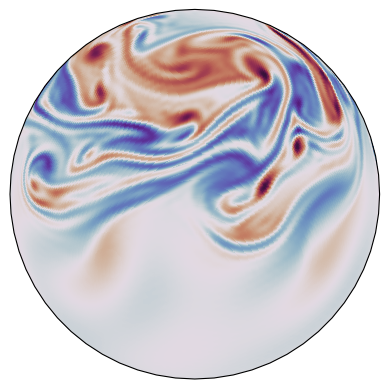

In [6]:
fig = plt.figure()
im = swe_solver.plot_specdata(uspec[1], fig, cmap="twilight_shifted")
plt.show()

## Animation

We render the full time series of the vorticity field as an animated GIF.
Set `plot_pvrt = True` to visualise potential vorticity instead:

Rendering frames: 100%|██████████| 277/277 [01:21<00:00,  3.42it/s]


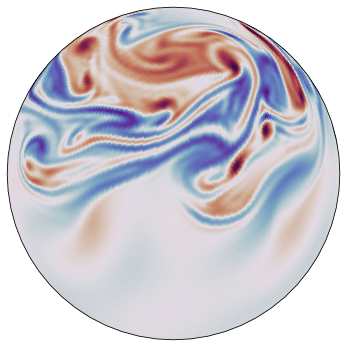

In [7]:
import os
os.makedirs("plots", exist_ok=True)

# prepare figure for animation
fig = plt.figure(figsize=(8, 6), dpi=72)
moviewriter = animation.writers['pillow'](fps=20)
moviewriter.setup(fig, './plots/zonal_jet.gif', dpi=72)

plot_pvrt = False

for i in tqdm(range(utspec.shape[0]), desc="Rendering frames"):
    t = i*nskip*dt

    if plot_pvrt:
        variable = swe_solver.potential_vorticity(utspec[i])
    else:
        variable = swe_solver.spec2grid(utspec[i, 1])

    plt.clf()
    swe_solver.plot_griddata(variable, fig, cmap="twilight_shifted", antialiased=False)
    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

## Conservation of potential vorticity

The potential vorticity $q = (\zeta + f) / \Phi$ is a materially
conserved quantity — it should remain constant following fluid parcels.
We verify this by computing the total spectral energy of $q$ at each
saved time step and checking that it stays close to its initial value:

In [8]:
pvrttspec = torch.zeros(floor(maxiter//nskip) + 1, lmax, mmax).cdouble().to(device)
for i in range(utspec.shape[0]):
    pvrttspec[i] = swe_solver.grid2spec(swe_solver.potential_vorticity(utspec[i]))

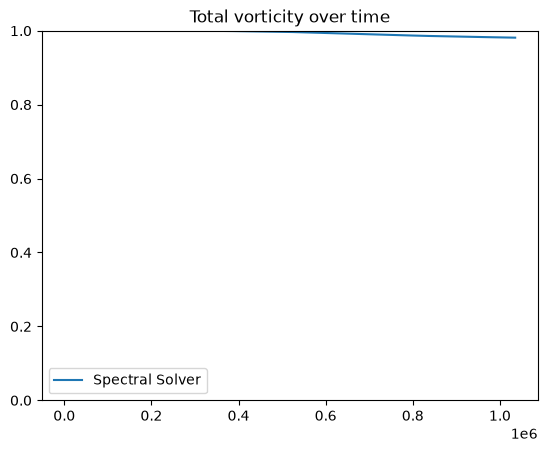

In [9]:
total_vrt = pvrttspec.abs()**2
# total_vrt = utspec[..., 1, :, :].abs()**2
total_vrt = torch.sqrt(torch.sum(total_vrt[..., :1], dim=(-1, -2)) + torch.sum(2 * total_vrt[..., 1:], dim=(-1, -2))).cpu()
t = nskip*dt * torch.arange(utspec.shape[0])

plt.plot(t, total_vrt / total_vrt[0], label='Spectral Solver')
plt.title('Total vorticity over time')
plt.ylim((0,1))
plt.legend(loc='lower left')